# RubricLLM — User Study Evaluation Pipeline

**Research Questions:**
1. Does iterative elicitation surface preferences that direct elicitation misses?
2. Does rubric-grounding improve LLM-as-judge alignment with user preferences?
3. Is LLM-as-judge evaluation reliable enough to drive this refinement loop?

In [148]:
# ============================================================
# Cell 1: Setup & Supabase Connection
# ============================================================

import os, json, re, copy
from datetime import datetime
from pathlib import Path
from collections import Counter, defaultdict

import toml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import kendalltau, wilcoxon, binomtest
from supabase import create_client

# --- Visualization defaults ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300, "savefig.bbox": "tight"})
PALETTE = sns.color_palette("colorblind")

# --- Output directories ---
OUT = Path("eval_output")
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "tables").mkdir(parents=True, exist_ok=True)
(OUT / "raw").mkdir(parents=True, exist_ok=True)

# --- Supabase connection ---
# Option 1: Service role key (bypasses RLS — preferred for eval)
# Set env var: export SUPABASE_SERVICE_ROLE_KEY=your_key
# Option 2: Anon key from secrets.toml (RLS applies — only sees authenticated user's data)

secrets = toml.load(".streamlit/secrets.toml")
SUPA_URL = secrets["SUPABASE_URL"]
SUPA_KEY = os.environ.get("SUPABASE_SERVICE_ROLE_KEY", secrets["SUPABASE_KEY"])

if "SUPABASE_SERVICE_ROLE_KEY" not in os.environ:
    print("⚠️  Using anon key — RLS is active. You may only see your own data.")
    print("   To see ALL users: export SUPABASE_SERVICE_ROLE_KEY=<your_service_role_key>")
    print("   Or run this SQL in Supabase to add a read-all policy for eval:")
    print("   CREATE POLICY \"eval_read_all\" ON public.projects FOR SELECT USING (true);")
    print("   (repeat for conversations, rubric_history, project_data)")

sb = create_client(SUPA_URL, SUPA_KEY)

# --- Fetch all tables ---
def fetch_all(table, page_size=1000):
    """Paginated fetch to handle tables with >1000 rows."""
    all_rows = []
    offset = 0
    while True:
        resp = sb.table(table).select("*").range(offset, offset + page_size - 1).execute()
        if not resp.data:
            break
        all_rows.extend(resp.data)
        if len(resp.data) < page_size:
            break
        offset += page_size
    return all_rows

raw_projects = fetch_all("projects")
raw_conversations = fetch_all("conversations")
raw_rubric_history = fetch_all("rubric_history")
raw_project_data = fetch_all("project_data")

print(f"Fetched: {len(raw_projects)} projects, {len(raw_conversations)} conversations, "
      f"{len(raw_rubric_history)} rubric versions, {len(raw_project_data)} project_data rows")

# --- Filter to specific user by user_id ---
FILTER_UID = "d6deaa1a-b797-415c-859c-bb998f9584bc"  # Nouran — set to None to include all

if FILTER_UID:
    raw_projects = [p for p in raw_projects if p.get("user_id") == FILTER_UID]
    filtered_pids = {p["id"] for p in raw_projects}
    raw_conversations = [c for c in raw_conversations if c["project_id"] in filtered_pids]
    raw_rubric_history = [r for r in raw_rubric_history if r["project_id"] in filtered_pids]
    raw_project_data = [d for d in raw_project_data if d["project_id"] in filtered_pids]
    print(f"Filtered to user {FILTER_UID}: {len(raw_projects)} projects, {len(raw_conversations)} conversations, "
          f"{len(raw_rubric_history)} rubric versions, {len(raw_project_data)} project_data rows")

⚠️  Using anon key — RLS is active. You may only see your own data.
   To see ALL users: export SUPABASE_SERVICE_ROLE_KEY=<your_service_role_key>
   Or run this SQL in Supabase to add a read-all policy for eval:
   CREATE POLICY "eval_read_all" ON public.projects FOR SELECT USING (true);
   (repeat for conversations, rubric_history, project_data)
Fetched: 21 projects, 39 conversations, 38 rubric versions, 49 project_data rows
Filtered to user d6deaa1a-b797-415c-859c-bb998f9584bc: 1 projects, 2 conversations, 2 rubric versions, 8 project_data rows


In [149]:
# Debug: list all projects we can see (user_id + project name)
print(f"Total projects visible: {len(raw_projects)}")
print(f"Unique user_ids: {len(set(p['user_id'] for p in raw_projects))}")
print()
for p in raw_projects:
    print(f"  user_id: {p['user_id']}  |  project: {p['name']}")

Total projects visible: 1
Unique user_ids: 1

  user_id: d6deaa1a-b797-415c-859c-bb998f9584bc  |  project: Email


In [150]:
# ============================================================
# Cell 2: Data Parsing — Flatten JSONB Into DataFrames
# ============================================================

# --- Build project -> user mapping ---
proj_to_user = {p["id"]: p["user_id"] for p in raw_projects}
proj_to_name = {p["id"]: p["name"] for p in raw_projects}

# --- Anonymize users ---
unique_users = sorted(set(proj_to_user.values()))
user_anon = {uid: f"P{i+1}" for i, uid in enumerate(unique_users)}
print(f"Found {len(unique_users)} unique users: {list(user_anon.values())}")

# --- Explode project_data into per-type record lists ---
records_by_type = defaultdict(list)
for row in raw_project_data:
    pid = row["project_id"]
    dtype = row["data_type"]
    data = row["data"]
    if isinstance(data, str):
        data = json.loads(data)
    if not isinstance(data, list):
        data = [data]
    uid = proj_to_user.get(pid, "unknown")
    for item in data:
        if isinstance(item, dict):
            item["_project_id"] = pid
            item["_user_id"] = uid
            item["_user"] = user_anon.get(uid, uid)
            records_by_type[dtype].append(item)

print("Data types found:", {k: len(v) for k, v in records_by_type.items()})

# --- Build DataFrames for each data type ---
df_probes = pd.DataFrame(records_by_type.get("probe_results", []))
df_classifications = pd.DataFrame(records_by_type.get("criteria_classification_feedback", []))
df_dp_feedback = pd.DataFrame(records_by_type.get("decision_point_feedback", []))
df_alignment = pd.DataFrame(records_by_type.get("alignment_diagnostic", []))
df_inline_rephrase = pd.DataFrame(records_by_type.get("inline_rephrase", []))
df_rubric_edits = pd.DataFrame(records_by_type.get("rubric_edit_applied", []))
df_build_eval = pd.DataFrame(records_by_type.get("build_evaluation", []))
df_grade_eval = pd.DataFrame(records_by_type.get("grade_evaluation", []))
df_retest = pd.DataFrame(records_by_type.get("grade_retest", []))
df_rubric_suggestions = pd.DataFrame(records_by_type.get("rubric_edit_suggestion", []))

# Survey: take last entry per user (canonical snapshot)
survey_records = records_by_type.get("survey_responses", [])
survey_by_user = {}
for s in survey_records:
    survey_by_user[s["_user"]] = s  # last one wins
df_survey = pd.DataFrame(list(survey_by_user.values())) if survey_by_user else pd.DataFrame()

# --- Parse conversations ---
conv_records = []
for c in raw_conversations:
    pid = c["project_id"]
    uid = proj_to_user.get(pid, "unknown")
    messages = c.get("messages", []) or []
    if isinstance(messages, str):
        messages = json.loads(messages)
    
    n_messages = len(messages)
    n_drafts = sum(1 for m in messages if re.search(r'<draft>.*?</draft>', m.get('content', ''), re.DOTALL))
    n_user = sum(1 for m in messages if m.get('role') == 'user')
    n_assistant = sum(1 for m in messages if m.get('role') == 'assistant')
    n_system = sum(1 for m in messages if m.get('role') == 'system')
    n_probe_logs = sum(1 for m in messages if m.get('is_probe_log'))
    n_rubric_revisions = sum(1 for m in messages if m.get('rubric_revision'))
    n_alignment_diag = sum(1 for m in messages if m.get('is_alignment_diagnostic'))
    n_inline_rephrase = sum(1 for m in messages if m.get('is_inline_rephrase'))
    n_classification = sum(1 for m in messages if m.get('is_criteria_classification_log'))
    n_dp_confirm = sum(1 for m in messages if m.get('is_dp_confirmation_log'))
    
    conv_records.append({
        "conversation_id": c["id"],
        "_project_id": pid,
        "_user_id": uid,
        "_user": user_anon.get(uid, uid),
        "n_messages": n_messages,
        "n_drafts": n_drafts,
        "n_user_msgs": n_user,
        "n_assistant_msgs": n_assistant,
        "n_system_msgs": n_system,
        "n_probe_logs": n_probe_logs,
        "n_rubric_revisions": n_rubric_revisions,
        "n_alignment_diag": n_alignment_diag,
        "n_inline_rephrase": n_inline_rephrase,
        "n_classification": n_classification,
        "n_dp_confirm": n_dp_confirm,
        "created_at": c.get("created_at", ""),
    })
df_conversations = pd.DataFrame(conv_records)

# --- Parse rubric history ---
rubric_records = []
for r in raw_rubric_history:
    pid = r["project_id"]
    uid = proj_to_user.get(pid, "unknown")
    rd = r.get("rubric_data", {})
    if isinstance(rd, str):
        rd = json.loads(rd)
    criteria = rd.get("rubric", []) if isinstance(rd, dict) else []
    rubric_records.append({
        "_project_id": pid,
        "_user_id": uid,
        "_user": user_anon.get(uid, uid),
        "version": r.get("version", 0),
        "n_criteria": len(criteria),
        "criteria_names": [c.get("name", "") for c in criteria],
        "source": rd.get("source", "") if isinstance(rd, dict) else "",
        "created_at": r.get("created_at", ""),
    })
df_rubric_versions = pd.DataFrame(rubric_records)

print(f"\nConversations: {len(df_conversations)} rows")
print(f"Rubric versions: {len(df_rubric_versions)} rows")
print(f"\nPer-user conversation counts:")
if not df_conversations.empty:
    print(df_conversations.groupby("_user").agg(
        conversations=("conversation_id", "count"),
        total_messages=("n_messages", "sum"),
        total_drafts=("n_drafts", "sum"),
    ).to_string())

Found 1 unique users: ['P1']
Data types found: {'coldstart_preferences': 1, 'alignment_diagnostic': 1, 'diagnostic_retest': 1, 'criteria_classification_feedback': 1, 'rubric_edit_applied': 1, 'infer_conversation': 1, 'decision_point_feedback': 1, 'survey_responses': 4}

Conversations: 2 rows
Rubric versions: 2 rows

Per-user conversation counts:
       conversations  total_messages  total_drafts
_user                                             
P1                 2              12             6


In [151]:
# ============================================================
# Cell 3: Per-User Aggregate Summaries for RQ1–RQ3
# ============================================================

# ---- RQ1: one row per user ----
rq1_rows = []
rq1_criteria_rows = []

for user in sorted(user_anon.values()):
    row = {"user": user}
    
    uc = df_classifications[df_classifications["_user"] == user] if not df_classifications.empty else pd.DataFrame()
    if not uc.empty:
        r = uc.iloc[-1]
        row["stated"] = r.get("stated_count", 0)
        row["real"] = r.get("real_count", 0)
        row["hallucinated"] = r.get("hallucinated_count", 0)
        row["precision"] = r.get("precision", np.nan)
        row["llm_user_agreement"] = r.get("llm_user_agreement", np.nan)
        
        classifications = r.get("classifications", {})
        importance_rank_map = r.get("importance_rank_map", {})
        importance_ranking = r.get("importance_ranking", [])
        if isinstance(classifications, str): classifications = json.loads(classifications)
        if isinstance(importance_rank_map, str): importance_rank_map = json.loads(importance_rank_map)
        if isinstance(importance_ranking, str): importance_ranking = json.loads(importance_ranking)
        
        total_criteria = len(classifications) if classifications else 1
        for crit_name, origin in (classifications or {}).items():
            rank = importance_rank_map.get(crit_name, np.nan) if importance_rank_map else np.nan
            if pd.isna(rank) and importance_ranking:
                try:
                    rank = importance_ranking.index(crit_name) + 1
                except ValueError:
                    rank = np.nan
            rq1_criteria_rows.append({
                "user": user, "criterion": crit_name, "origin": origin,
                "importance_rank": rank, "n_criteria": total_criteria,
                "normalized_rank": rank / total_criteria if pd.notna(rank) and total_criteria > 0 else np.nan,
            })
    else:
        row.update({"stated": 0, "real": 0, "hallucinated": 0, "precision": np.nan, "llm_user_agreement": np.nan})
    
    total = row.get("stated", 0) + row.get("real", 0) + row.get("hallucinated", 0)
    row["total_criteria"] = total
    row["stated_rate"] = row.get("stated", 0) / total if total > 0 else np.nan
    row["real_rate"] = row.get("real", 0) / total if total > 0 else np.nan
    row["hallucinated_rate"] = row.get("hallucinated", 0) / total if total > 0 else np.nan
    
    ua = df_alignment[df_alignment["_user"] == user] if not df_alignment.empty else pd.DataFrame()
    if not ua.empty:
        ranking = ua.iloc[-1].get("user_ranking", [])
        if isinstance(ranking, str): ranking = json.loads(ranking)
        row["rubric_rank"] = (ranking.index("rubric") + 1) if "rubric" in ranking else np.nan
        row["n_drafts_compared"] = len(ranking)
    else:
        row["rubric_rank"] = np.nan
        row["n_drafts_compared"] = np.nan
    
    rq1_rows.append(row)

df_rq1 = pd.DataFrame(rq1_rows)
df_rq1.to_csv(OUT / "tables" / "rq1_per_user.csv", index=False)

df_rq1_criteria = pd.DataFrame(rq1_criteria_rows)

# --- MOCK DATA: fill in importance ranks where missing ---
USE_MOCK_IMPORTANCE = True  # <-- set to False once real importance data is collected
if USE_MOCK_IMPORTANCE and not df_rq1_criteria.empty:
    missing = df_rq1_criteria["importance_rank"].isna()
    if missing.all():
        mock_ranking = {
            "Relational Positioning": 1,
            "Structured Multi-party Address": 2,
            "Justified Reasoning and Actionable Closure": 3,
            "Warm Professional Tone": 4,
            "Formatting Conventions": 5,
            "Semantic Precision": 6,
        }
        for idx, row in df_rq1_criteria.iterrows():
            crit = row["criterion"]
            if crit in mock_ranking:
                df_rq1_criteria.at[idx, "importance_rank"] = mock_ranking[crit]
                df_rq1_criteria.at[idx, "normalized_rank"] = mock_ranking[crit] / row["n_criteria"]
        print("(!) Using MOCK importance rankings — set USE_MOCK_IMPORTANCE = False when real data is collected")

if not df_rq1_criteria.empty:
    df_rq1_criteria.to_csv(OUT / "tables" / "rq1_criteria_importance.csv", index=False)

# ---- RQ2: Rubric-grounding & judge alignment ----
CONDITIONS_DRAFT = ["generic", "pref_desc", "rubric"]
COND_LABELS = {"generic": "Generic", "cold_start": "Cold-start", "rubric": "Rubric",
               "pref_desc": "Pref-desc", "preference": "Pref-desc"}

# (a) Per-user, per-draft rank pairs: user rank vs rubric judge rank
rq2_rank_pair_rows = []
# (b) Per-user, per-condition reliability (exact + within-1 agreement)
rq2_reliability_rows = []
# (c) Draft preference picks
rq2_draft_pref_rows = []

for user in sorted(user_anon.values()):
    ua = df_alignment[df_alignment["_user"] == user] if not df_alignment.empty else pd.DataFrame()
    if not ua.empty:
        arow = ua.iloc[-1]
        user_ranking = arow.get("user_ranking", [])
        shuffle_order = arow.get("shuffle_order", [])
        rubric_judge = arow.get("rubric_judge_result", {})
        is_3draft = arow.get("is_3draft", False)
        
        if isinstance(user_ranking, str): user_ranking = json.loads(user_ranking)
        if isinstance(shuffle_order, str): shuffle_order = json.loads(shuffle_order)
        if isinstance(rubric_judge, str): rubric_judge = json.loads(rubric_judge)
        
        # Build label->source mapping from shuffle_order
        label_to_source = {}
        for pair in (shuffle_order or []):
            if isinstance(pair, (list, tuple)) and len(pair) == 2:
                label_to_source[pair[0]] = pair[1]
        
        # User ranking: source name order → rank 1,2,3
        user_rank_map = {src: i + 1 for i, src in enumerate(user_ranking)}
        
        # Rubric judge ranking: overall_ranking like ['DRAFT_C','DRAFT_B','DRAFT_A']
        rj_ranking = rubric_judge.get("overall_ranking", [])
        rj_rank_map = {}
        if rj_ranking and is_3draft:
            for rank_idx, draft_label in enumerate(rj_ranking):
                letter = draft_label.replace("DRAFT_", "").replace("draft_", "")
                source = label_to_source.get(letter, label_to_source.get(letter.upper()))
                if source:
                    rj_rank_map[source] = rank_idx + 1
        
        # Normalize source names to condition labels
        source_to_cond = {"rubric": "rubric", "generic": "generic", "preference": "pref_desc"}
        
        # Emit one row per draft per user (for panel a)
        for src in user_rank_map:
            cond = source_to_cond.get(src, src)
            rq2_rank_pair_rows.append({
                "user": user,
                "condition": cond,
                "user_rank": user_rank_map[src],
                "judge_rank": rj_rank_map.get(src, np.nan),
            })
        
        # Emit draft preference rows (for panel c)
        for src_i, src in enumerate(user_ranking):
            cond = source_to_cond.get(src, src)
            rq2_draft_pref_rows.append({
                "user": user, "condition": cond, "rank": src_i + 1
            })

# (b) Extract reliability from diagnostic_retest raw scores
df_diag_retest = pd.DataFrame(records_by_type.get("diagnostic_retest", []))
for user in sorted(user_anon.values()):
    ur = df_diag_retest[df_diag_retest["_user"] == user] if not df_diag_retest.empty else pd.DataFrame()
    if not ur.empty:
        item = ur.iloc[-1]
        for cond_key, result_key in [("rubric", "retest_rubric_result"), ("generic", "retest_generic_result")]:
            result = item.get(result_key, {})
            if isinstance(result, str): result = json.loads(result)
            if not result or not isinstance(result, dict):
                continue
            per_crit = result.get("per_criterion", [])
            if not per_crit:
                continue
            orig_key = "original_rubric_result" if cond_key == "rubric" else "original_generic_result"
            orig_result = item.get(orig_key, {})
            if isinstance(orig_result, str): orig_result = json.loads(orig_result)
            orig_per_crit = orig_result.get("per_criterion", []) if orig_result else []
            
            run1_scores, run2_scores = [], []
            for crit in per_crit:
                run2_scores.append(crit.get("draft_a_score", np.nan))
                run2_scores.append(crit.get("draft_b_score", np.nan))
            for crit in orig_per_crit:
                run1_scores.append(crit.get("draft_a_score", np.nan))
                run1_scores.append(crit.get("draft_b_score", np.nan))
            
            if run1_scores and run2_scores and len(run1_scores) == len(run2_scores):
                r1 = np.array(run1_scores, dtype=float)
                r2 = np.array(run2_scores, dtype=float)
                valid = ~(np.isnan(r1) | np.isnan(r2))
                if valid.sum() > 0:
                    diffs = np.abs(r1[valid] - r2[valid])
                    rq2_reliability_rows.append({
                        "user": user, "condition": cond_key,
                        "exact_agreement": float(np.mean(diffs == 0)),
                        "within1_agreement": float(np.mean(diffs <= 1)),
                        "mean_abs_diff": float(np.mean(diffs)),
                        "n_scores": int(valid.sum()),
                    })
    
    # Fallback: check grade_retest if no diagnostic_retest found
    if not any(r["user"] == user for r in rq2_reliability_rows):
        ur2 = df_retest[df_retest["_user"] == user] if not df_retest.empty else pd.DataFrame()
        if not ur2.empty:
            m = ur2.iloc[-1].get("metrics", {})
            if isinstance(m, str): m = json.loads(m)
            if isinstance(m, dict):
                for cond_key in ["rubric", "generic"]:
                    r1 = m.get(f"{cond_key}_run1_scores", [])
                    r2 = m.get(f"{cond_key}_run2_scores", [])
                    if r1 and r2 and len(r1) == len(r2):
                        r1a, r2a = np.array(r1, dtype=float), np.array(r2, dtype=float)
                        diffs = np.abs(r1a - r2a)
                        rq2_reliability_rows.append({
                            "user": user, "condition": cond_key,
                            "exact_agreement": float(np.mean(diffs == 0)),
                            "within1_agreement": float(np.mean(diffs <= 1)),
                            "mean_abs_diff": float(np.mean(diffs)),
                            "n_scores": len(r1),
                        })

df_rq2_rank_pairs = pd.DataFrame(rq2_rank_pair_rows)
df_rq2_reliability = pd.DataFrame(rq2_reliability_rows)
df_rq2_draft_pref = pd.DataFrame(rq2_draft_pref_rows)

# Build per-user summary for RQ2
rq2_rows = []
for user in sorted(user_anon.values()):
    row = {"user": user}
    
    ur = df_rq2_rank_pairs[df_rq2_rank_pairs["user"] == user] if not df_rq2_rank_pairs.empty else pd.DataFrame()
    for cond in CONDITIONS_DRAFT:
        uc = ur[ur["condition"] == cond] if not ur.empty else pd.DataFrame()
        row[f"user_rank_{cond}"] = uc["user_rank"].values[0] if not uc.empty else np.nan
        row[f"judge_rank_{cond}"] = uc["judge_rank"].values[0] if not uc.empty else np.nan
    
    rl = df_rq2_reliability[df_rq2_reliability["user"] == user] if not df_rq2_reliability.empty else pd.DataFrame()
    for cond in ["generic", "rubric"]:
        uc = rl[rl["condition"] == cond] if not rl.empty else pd.DataFrame()
        row[f"exact_agree_{cond}"] = uc["exact_agreement"].values[0] if not uc.empty else np.nan
        row[f"within1_agree_{cond}"] = uc["within1_agreement"].values[0] if not uc.empty else np.nan
    
    ud = df_rq2_draft_pref[df_rq2_draft_pref["user"] == user] if not df_rq2_draft_pref.empty else pd.DataFrame()
    for cond in CONDITIONS_DRAFT:
        uc = ud[ud["condition"] == cond] if not ud.empty else pd.DataFrame()
        row[f"draft_rank_{cond}"] = uc["rank"].values[0] if not uc.empty else np.nan
    
    rq2_rows.append(row)

df_rq2 = pd.DataFrame(rq2_rows)
df_rq2.to_csv(OUT / "tables" / "rq2_per_user.csv", index=False)

# ---- RQ3: Per-criterion classification trajectory across diagnostics ----
CLASS_ORDER = ["DIFFERENTIATING", "REDUNDANT", "PREFERENCE_GAP", "UNDERPERFORMING"]

rq3_crit_rows = []  # per-user, per-version, per-criterion
rq3_version_rows = []  # per-user, per-version summary

for user in sorted(user_anon.values()):
    ua = df_alignment[df_alignment["_user"] == user] if not df_alignment.empty else pd.DataFrame()
    if ua.empty:
        continue
    
    # Sort by rubric_version (or timestamp) to get temporal order
    ua_sorted = ua.sort_values("rubric_version") if "rubric_version" in ua.columns else ua
    
    for _, arow in ua_sorted.iterrows():
        version = arow.get("rubric_version", 0)
        criteria_analysis = arow.get("criteria_analysis", [])
        if isinstance(criteria_analysis, str):
            criteria_analysis = json.loads(criteria_analysis)
        if not criteria_analysis:
            continue
        
        version_counts = Counter()
        version_gaps = []
        
        for crit in criteria_analysis:
            cname = crit.get("name", "?")
            classification = crit.get("classification", "UNKNOWN")
            gap = crit.get("gap", 0)
            rubric_score = crit.get("rubric_score", np.nan)
            generic_score = crit.get("generic_score", np.nan)
            
            rq3_crit_rows.append({
                "user": user,
                "rubric_version": version,
                "criterion": cname,
                "classification": classification,
                "gap": gap,
                "rubric_score": rubric_score,
                "generic_score": generic_score,
            })
            
            version_counts[classification] += 1
            if gap is not None:
                version_gaps.append(gap)
        
        n_crit = len(criteria_analysis)
        rq3_version_rows.append({
            "user": user,
            "rubric_version": version,
            "n_criteria": n_crit,
            "n_differentiating": version_counts.get("DIFFERENTIATING", 0),
            "n_redundant": version_counts.get("REDUNDANT", 0),
            "n_preference_gap": version_counts.get("PREFERENCE_GAP", 0),
            "n_underperforming": version_counts.get("UNDERPERFORMING", 0),
            "pct_differentiating": version_counts.get("DIFFERENTIATING", 0) / n_crit if n_crit else 0,
            "mean_gap": float(np.mean(version_gaps)) if version_gaps else 0,
        })

df_rq3_criteria = pd.DataFrame(rq3_crit_rows)
df_rq3_versions = pd.DataFrame(rq3_version_rows)

if not df_rq3_criteria.empty:
    df_rq3_criteria.to_csv(OUT / "tables" / "rq3_criteria_trajectory.csv", index=False)
if not df_rq3_versions.empty:
    df_rq3_versions.to_csv(OUT / "tables" / "rq3_version_summary.csv", index=False)

print("Per-user aggregates:")
print(f"  df_rq1: {len(df_rq1)} users")
display(df_rq1)
print(f"\n  df_rq1_criteria: {len(df_rq1_criteria)} criteria across all users")
if not df_rq1_criteria.empty: display(df_rq1_criteria)
print(f"\n  df_rq2: {len(df_rq2)} users")
display(df_rq2)
print(f"\n  df_rq2_rank_pairs: {len(df_rq2_rank_pairs)} rows (user vs judge rank per draft)")
if not df_rq2_rank_pairs.empty: display(df_rq2_rank_pairs)
print(f"\n  df_rq2_reliability: {len(df_rq2_reliability)} rows (exact + within-1 agreement)")
if not df_rq2_reliability.empty: display(df_rq2_reliability)
print(f"\n  df_rq3_criteria: {len(df_rq3_criteria)} rows (per-criterion, per-version)")
if not df_rq3_criteria.empty: display(df_rq3_criteria)
print(f"\n  df_rq3_versions: {len(df_rq3_versions)} rows (per-version summary)")
if not df_rq3_versions.empty: display(df_rq3_versions)

(!) Using MOCK importance rankings — set USE_MOCK_IMPORTANCE = False when real data is collected
Per-user aggregates:
  df_rq1: 1 users


,user,stated,real,hallucinated,precision,llm_user_agreement,total_criteria,stated_rate,real_rate,hallucinated_rate,rubric_rank,n_drafts_compared
0,P1,2,4,0,1.0,1.0,6,0.333333,0.666667,0.0,1,3



  df_rq1_criteria: 6 criteria across all users


,user,criterion,origin,importance_rank,n_criteria,normalized_rank
0,P1,Relational Positioning,real,1.0,6,0.166667
1,P1,Semantic Precision,stated,6.0,6,1.000000
2,P1,Warm Professional Tone,stated,4.0,6,0.666667
3,P1,Structured Multi-party Address,real,2.0,6,0.333333
4,P1,Formatting Conventions,real,5.0,6,0.833333
5,P1,Justified Reasoning and Actionable Closure,real,3.0,6,0.500000



  df_rq2: 1 users


...

,user,condition,exact_agreement,within1_agreement,mean_abs_diff,n_scores
0,P1,rubric,0.666667,1.0,0.333333,12
1,P1,generic,1.000000,1.0,0.000000,12



  df_rq3_criteria: 6 rows (per-criterion, per-version)


,user,rubric_version,criterion,classification,gap,rubric_score,generic_score
0,P1,1,Relational Positioning,REDUNDANT,0,4,4
1,P1,1,Semantic Precision,REDUNDANT,0,4,4
2,P1,1,Warm Professional Tone,PREFERENCE_GAP,0,4,4
3,P1,1,Structured Multi-party Address,REDUNDANT,0,4,4
4,P1,1,Formatting Conventions,REDUNDANT,0,4,4
5,P1,1,Justified Reasoning and Actionable Closure,REDUNDANT,0,4,4



  df_rq3_versions: 1 rows (per-version summary)


,user,rubric_version,n_criteria,n_differentiating,n_redundant,n_preference_gap,n_underperforming,pct_differentiating,mean_gap
0,P1,1,6,0,5,1,0,0.0,0.0


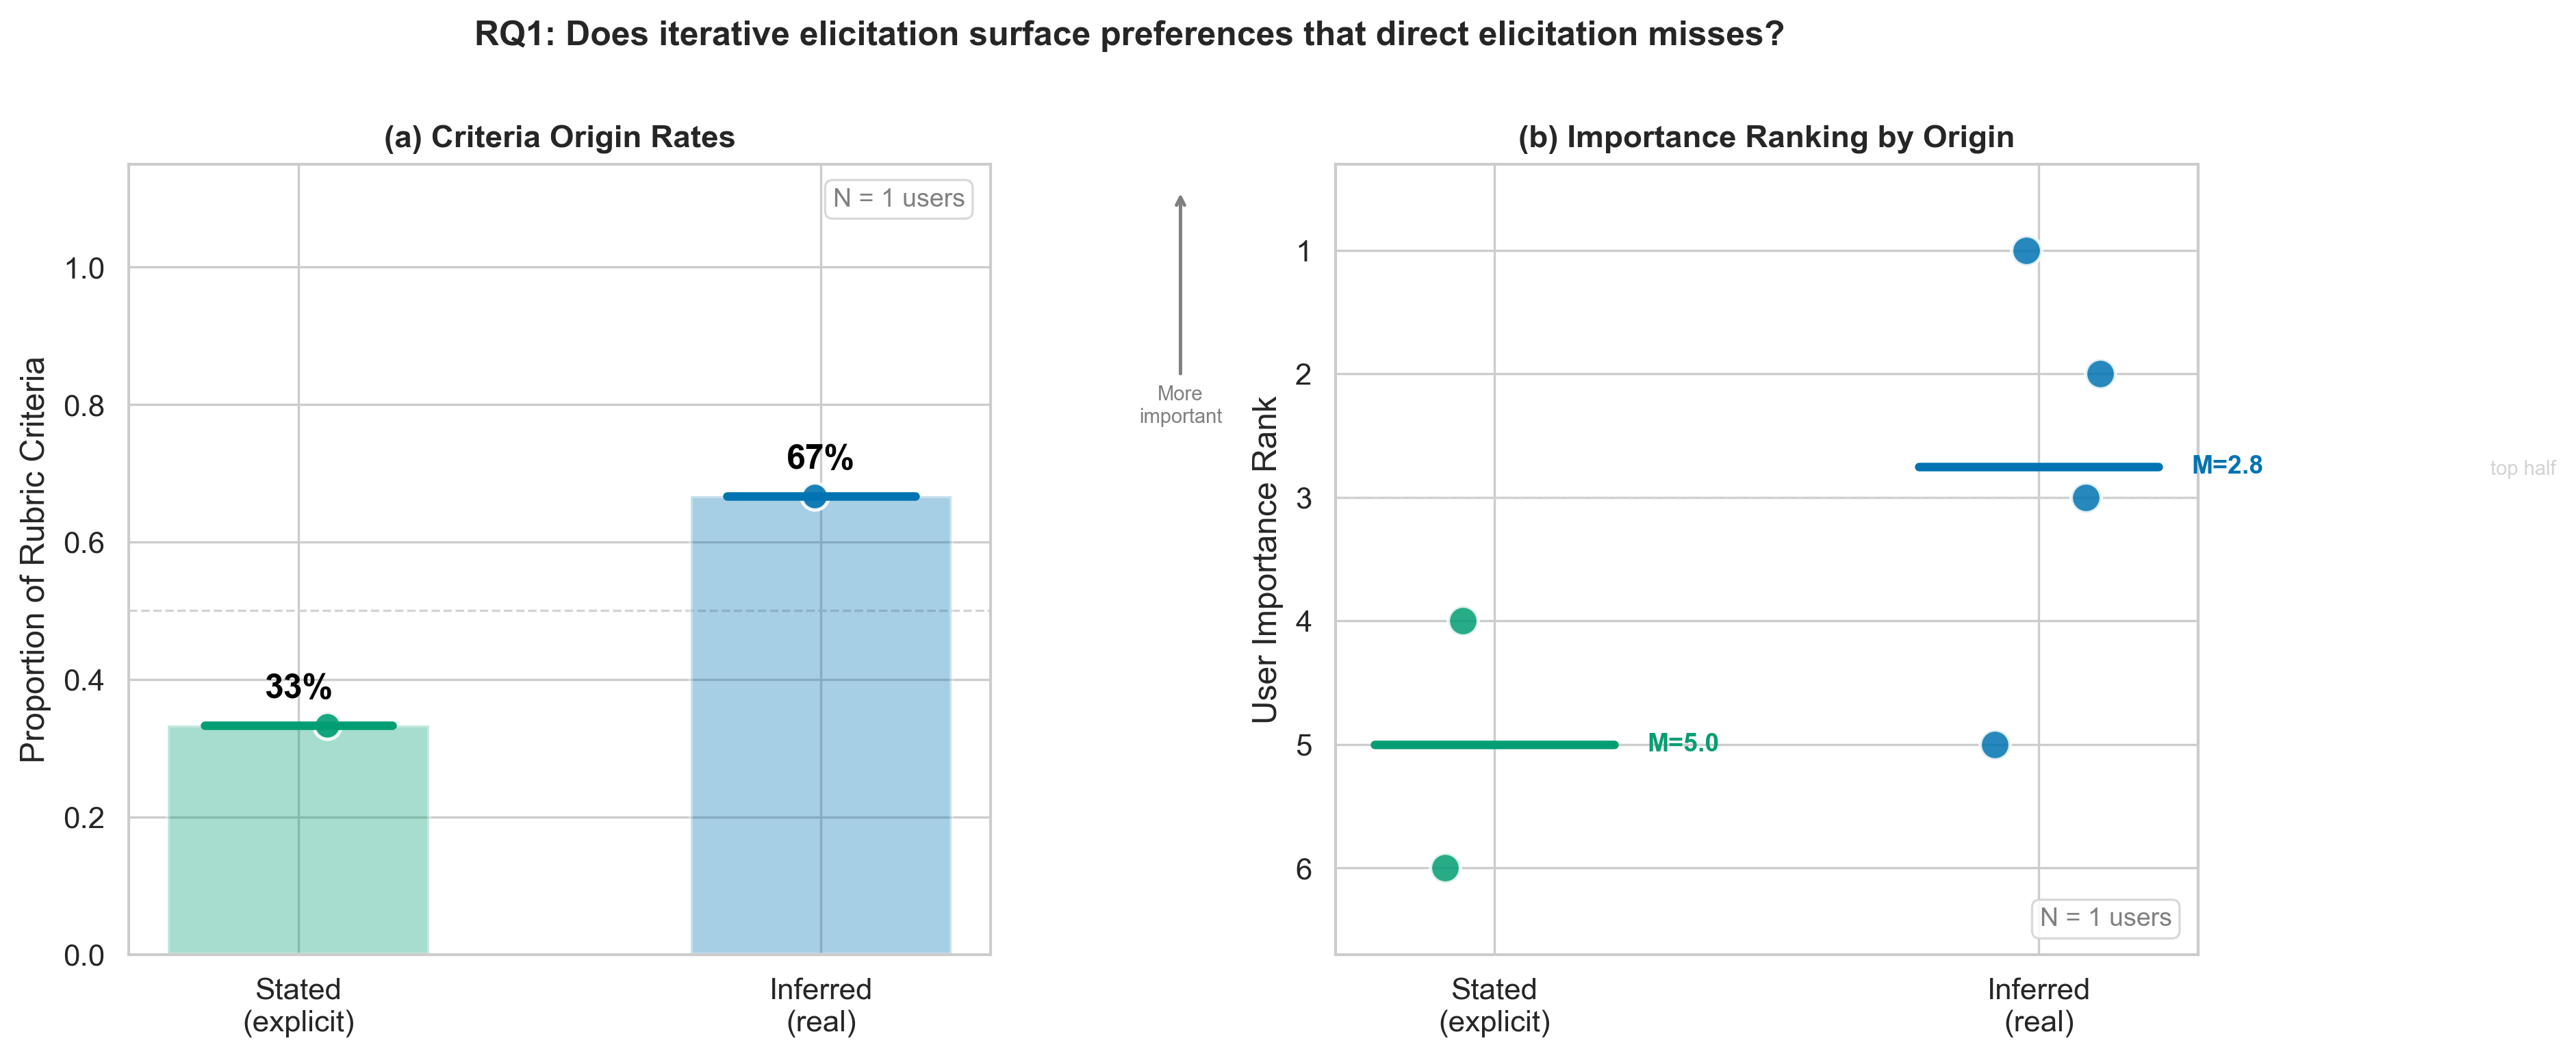

N = 1 users with classification data


In [152]:
# ============================================================
# RQ1 — Does iterative elicitation surface preferences
#        that direct elicitation misses?
# ============================================================
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.subplots_adjust(wspace=0.4)
d = df_rq1[df_rq1["precision"].notna()]
N = len(d)

# ---- (a) Precision & Real Rate ----
ax = axes[0]
if not d.empty:
    total_all = d["total_criteria"].sum()
    pooled_stated_rate = d["stated"].sum() / total_all if total_all else 0
    pooled_real_rate = d["real"].sum() / total_all if total_all else 0
    
    metrics = ["Stated\n(explicit)", "Inferred\n(real)"]
    pooled_vals = [pooled_stated_rate, pooled_real_rate]
    bar_colors = [PALETTE[2], PALETTE[0]]
    
    bars = ax.bar(metrics, pooled_vals, color=bar_colors, width=0.5,
                  edgecolor="white", linewidth=1.5, alpha=0.35, zorder=2)
    
    # Individual user dots overlaid
    rate_cols = ["stated_rate", "real_rate"]
    jitter_rng = np.random.default_rng(42)
    for i, (col, color) in enumerate(zip(rate_cols, bar_colors)):
        vals = d[col].dropna()
        if not vals.empty:
            jitter = jitter_rng.uniform(-0.1, 0.1, size=len(vals))
            ax.scatter(np.full(len(vals), i) + jitter, vals, s=90,
                       color=color, edgecolors="white", linewidth=1.2,
                       zorder=4, alpha=0.9)
            ax.plot([i - 0.18, i + 0.18], [vals.mean(), vals.mean()],
                    color=color, linewidth=3, zorder=5)
    
    for bar, v in zip(bars, pooled_vals):
        ax.text(bar.get_x() + bar.get_width()/2, max(v, 0.02) + 0.04,
                f"{v:.0%}", ha="center", fontsize=12, fontweight="bold", color="black")
    
    ax.set_ylabel("Proportion of Rubric Criteria")
    ax.set_ylim(0, 1.15)
    ax.axhline(0.5, color="lightgray", linestyle="--", linewidth=0.8, zorder=1)
    ax.text(0.97, 0.97, f"N = {N} users",
            transform=ax.transAxes, ha="right", va="top", fontsize=9, color="gray",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="lightgray"))
else:
    ax.text(0.5, 0.5, "No classification data", ha="center", va="center", transform=ax.transAxes)
ax.set_title("(a) Criteria Origin Rates", fontweight="bold", fontsize=11)

# ---- (b) Importance Ranking by Origin ----
ax = axes[1]
crit = df_rq1_criteria.copy() if not df_rq1_criteria.empty else pd.DataFrame()
# Only stated and real
crit = crit[crit["origin"].isin(["stated", "real"])] if not crit.empty else crit
crit_with_rank = crit[crit["importance_rank"].notna()] if not crit.empty else pd.DataFrame()

if not crit_with_rank.empty:
    origin_order = ["stated", "real"]
    origin_labels = ["Stated\n(explicit)", "Inferred\n(real)"]
    origin_colors = [PALETTE[2], PALETTE[0]]
    
    max_rank = crit_with_rank["importance_rank"].max()
    jitter_rng = np.random.default_rng(44)
    
    for i, (origin, label, color) in enumerate(zip(origin_order, origin_labels, origin_colors)):
        subset = crit_with_rank[crit_with_rank["origin"] == origin]
        if not subset.empty:
            jitter = jitter_rng.uniform(-0.12, 0.12, size=len(subset))
            ax.scatter(np.full(len(subset), i) + jitter, subset["importance_rank"],
                       s=110, color=color, edgecolors="white", linewidth=1.2,
                       zorder=3, alpha=0.85)
            mean_rank = subset["importance_rank"].mean()
            ax.plot([i - 0.22, i + 0.22], [mean_rank, mean_rank],
                    color=color, linewidth=3, zorder=4)
            ax.text(i + 0.28, mean_rank, f"M={mean_rank:.1f}",
                    va="center", fontsize=9, color=color, fontweight="bold")
    
    ax.set_xticks(range(len(origin_labels)))
    ax.set_xticklabels(origin_labels)
    ax.set_ylabel("User Importance Rank")
    ax.set_ylim(0.3, max_rank + 0.7)
    ax.invert_yaxis()

    # Directional arrow on y-axis to clarify inverted ranking
    ax.annotate("More\nimportant",
                xy=(-0.18, 0.97), xycoords="axes fraction",
                xytext=(-0.18, 0.72), textcoords="axes fraction",
                fontsize=7, color="gray", ha="center", va="top",
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.2))
    
    mid = max_rank / 2
    ax.axhline(mid, color="lightgray", linestyle="--", linewidth=0.8, zorder=1)
    ax.text(len(origin_order) - 0.05, mid - 0.15, "top half", fontsize=7,
            color="lightgray", ha="right", va="bottom")
    
    ax.text(0.97, 0.03, f"N = {N} users",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="gray",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="lightgray"))
else:
    ax.text(0.5, 0.55, "Importance ranking data\nnot yet available", ha="center", va="center",
            transform=ax.transAxes, fontsize=11, color="gray")
    ax.text(0.5, 0.35,
            "Users rank criteria by importance after\n"
            "classification. If inferred criteria appear\n"
            "in the top ranks, the conversation surfaced\n"
            "deeply-held but unarticulated preferences.",
            ha="center", va="center", transform=ax.transAxes, fontsize=8.5,
            color="lightgray", style="italic")
ax.set_title("(b) Importance Ranking by Origin", fontweight="bold", fontsize=11)

fig.suptitle("RQ1: Does iterative elicitation surface preferences that direct elicitation misses?",
             fontsize=12, fontweight="bold", y=1.02)
fig.savefig(OUT / "figures" / "fig01_rq1.pdf", bbox_inches="tight")
fig.savefig(OUT / "figures" / "fig01_rq1.png", bbox_inches="tight")
plt.show()
print(f"N = {N} users with classification data")

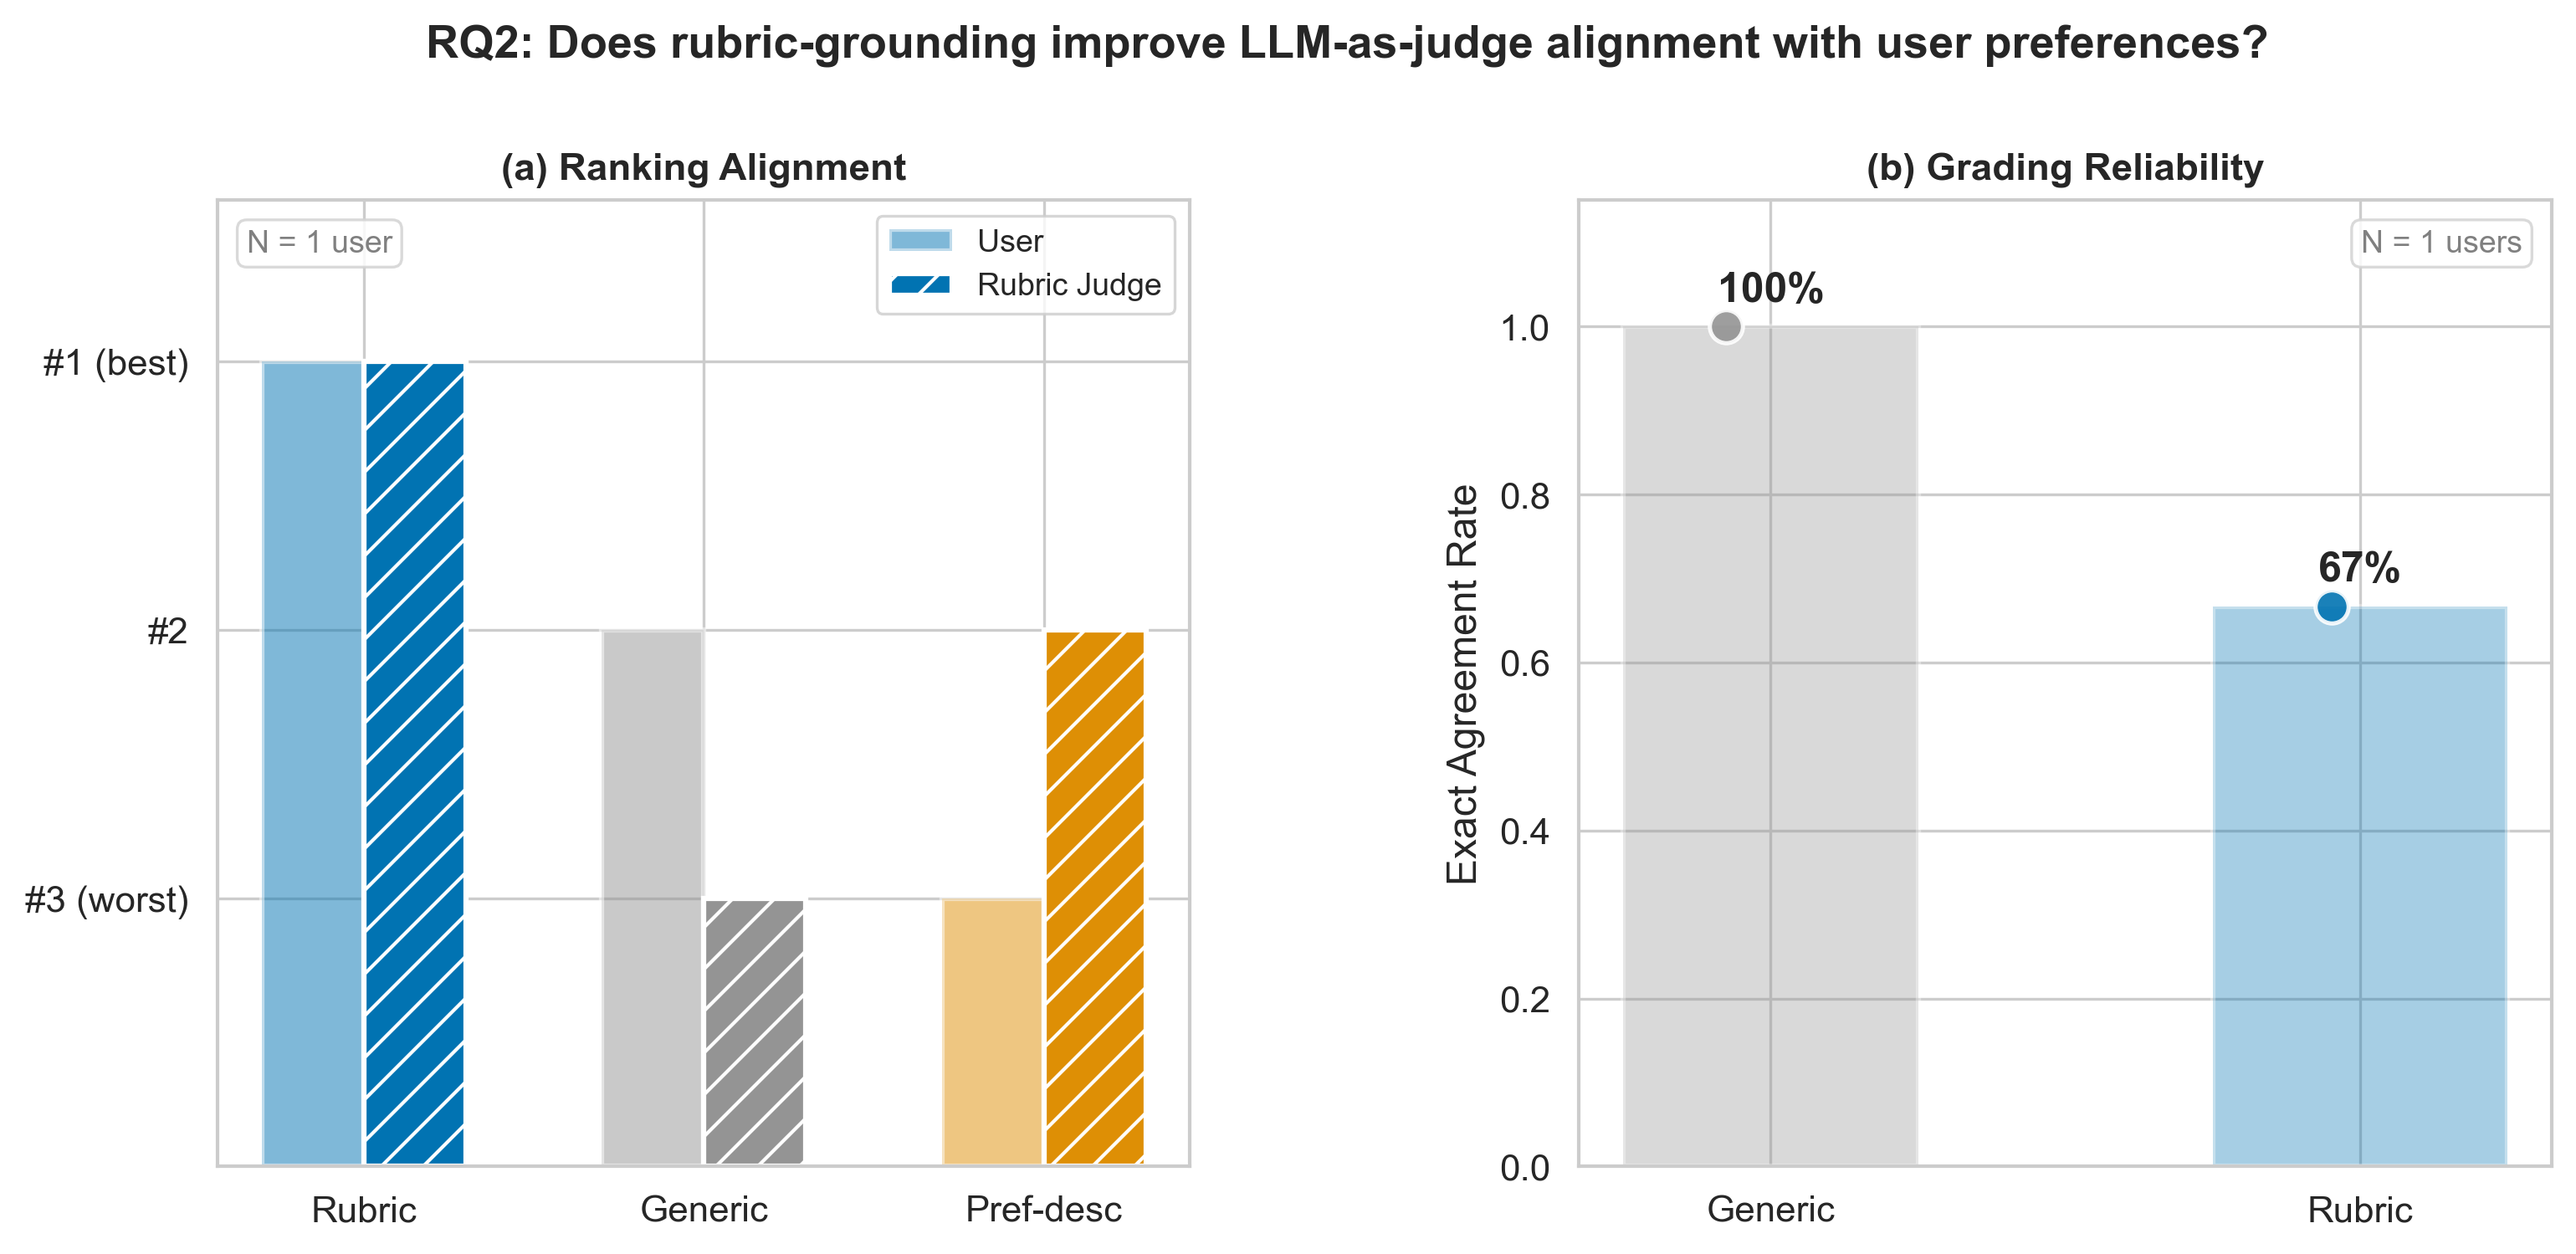

N = 1 users with RQ2 data


In [153]:
# ============================================================
# RQ2 — Does rubric-grounding improve LLM-as-judge alignment
#        with user preferences?
# ============================================================
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.subplots_adjust(wspace=0.4)

DRAFT_LABELS = {"generic": "Generic", "pref_desc": "Pref-desc", "rubric": "Rubric"}
DRAFT_COLORS = {"generic": PALETTE[7], "pref_desc": PALETTE[1], "rubric": PALETTE[0]}

N2 = len(df_rq2)

# ---- (a) Ranking Alignment: Grouped Bars (mean rank, inverted so #1 is tallest) ----
ax = axes[0]
conds = ["rubric", "generic", "pref_desc"]
if not df_rq2_rank_pairs.empty:
    users_with_data = df_rq2_rank_pairs["user"].unique()
    n_users = len(users_with_data)

    x = np.arange(len(conds))
    width = 0.3
    u_means = [df_rq2_rank_pairs[(df_rq2_rank_pairs["condition"] == d)]["user_rank"].mean() for d in conds]
    j_means = [df_rq2_rank_pairs[(df_rq2_rank_pairs["condition"] == d)]["judge_rank"].mean() for d in conds]

    # Invert: score = 4 - rank, so #1 → 3 (tallest), #3 → 1 (shortest)
    n_drafts = 3
    u_scores = [n_drafts + 1 - m for m in u_means]
    j_scores = [n_drafts + 1 - m for m in j_means]
    colors = [DRAFT_COLORS[d] for d in conds]

    bars1 = ax.bar(x - width/2, u_scores, width, color=colors, alpha=0.5,
                   edgecolor="white", linewidth=1.5, label="User")
    bars2 = ax.bar(x + width/2, j_scores, width, color=colors, alpha=1.0,
                   edgecolor="white", linewidth=1.5, hatch="//", label="Rubric Judge")

    ax.set_xticks(x)
    ax.set_xticklabels([DRAFT_LABELS[d] for d in conds])
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(["#3 (worst)", "#2", "#1 (best)"])
    ax.set_ylim(0, 3.6)
    ax.set_ylabel("")
    ax.legend(fontsize=9, loc="upper right")
    ax.text(0.03, 0.97, f"N = {n_users} {'user' if n_users == 1 else 'users'}",
            transform=ax.transAxes, ha="left", va="top", fontsize=9, color="gray",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="lightgray"))
else:
    ax.text(0.5, 0.55, "Awaiting data", ha="center", va="center",
            transform=ax.transAxes, fontsize=12, color="gray")
    ax.text(0.5, 0.35,
            "User and rubric-grounded judge each\n"
            "rank 3 blind drafts. Grouped bars show\n"
            "mean rank per draft condition.",
            ha="center", va="center", transform=ax.transAxes, fontsize=8.5,
            color="lightgray", style="italic")
ax.set_title("(a) Ranking Alignment", fontweight="bold", fontsize=11)

# ---- (b) Grading Reliability: Exact Agreement Rate ----
ax = axes[1]
if not df_rq2_reliability.empty:
    conds_rel = ["generic", "rubric"]
    x_pos = np.arange(len(conds_rel))
    colors_rel = [DRAFT_COLORS.get(c, PALETTE[7]) for c in conds_rel]

    pooled = df_rq2_reliability.groupby("condition")["exact_agreement"].mean()
    bar_vals = [pooled.get(c, 0) for c in conds_rel]

    bars = ax.bar(x_pos, bar_vals, color=colors_rel, width=0.5,
                  edgecolor="white", linewidth=1.5, alpha=0.35, zorder=2)

    jitter_rng = np.random.default_rng(44)
    for i, cond in enumerate(conds_rel):
        vals = df_rq2_reliability[df_rq2_reliability["condition"] == cond]["exact_agreement"]
        if not vals.empty:
            jitter = jitter_rng.uniform(-0.1, 0.1, size=len(vals))
            ax.scatter(np.full(len(vals), i) + jitter, vals, s=90,
                       color=colors_rel[i], edgecolors="white", linewidth=1.2, zorder=4, alpha=0.9)

    for bar, v in zip(bars, bar_vals):
        ax.text(bar.get_x() + bar.get_width()/2, max(v, 0.02) + 0.03,
                f"{v:.0%}", ha="center", fontsize=12, fontweight="bold")

    ax.set_xticks(x_pos)
    ax.set_xticklabels([COND_LABELS.get(c, c) for c in conds_rel])
    ax.set_ylabel("Exact Agreement Rate")
    ax.set_ylim(0, 1.15)
    # ax.axhline(0.8, color=PALETTE[2], linestyle="--", linewidth=1, alpha=0.4)
    ax.text(0.97, 0.97, f"N = {N2} users",
            transform=ax.transAxes, ha="right", va="top", fontsize=9, color="gray",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="lightgray"))
else:
    ax.text(0.5, 0.55, "Awaiting data", ha="center", va="center",
            transform=ax.transAxes, fontsize=12, color="gray")
    ax.text(0.5, 0.35,
            "Same judge grades the same drafts twice.\n"
            "Exact agreement = % of criterion-draft\n"
            "scores identical across both runs.",
            ha="center", va="center", transform=ax.transAxes, fontsize=8.5,
            color="lightgray", style="italic")
ax.set_title("(b) Grading Reliability", fontweight="bold", fontsize=11)

fig.suptitle("RQ2: Does rubric-grounding improve LLM-as-judge alignment with user preferences?",
             fontsize=13, fontweight="bold", y=1.02)
fig.savefig(OUT / "figures" / "fig02_rq2.pdf", bbox_inches="tight")
fig.savefig(OUT / "figures" / "fig02_rq2.png", bbox_inches="tight")
plt.show()

# Status report
status = []
if df_rq2_rank_pairs.empty: status.append("(a) ranking alignment")
if df_rq2_reliability.empty: status.append("(b) grading reliability")
if status:
    print(f"Awaiting data for: {', '.join(status)}")
else:
    print(f"N = {N2} users with RQ2 data")

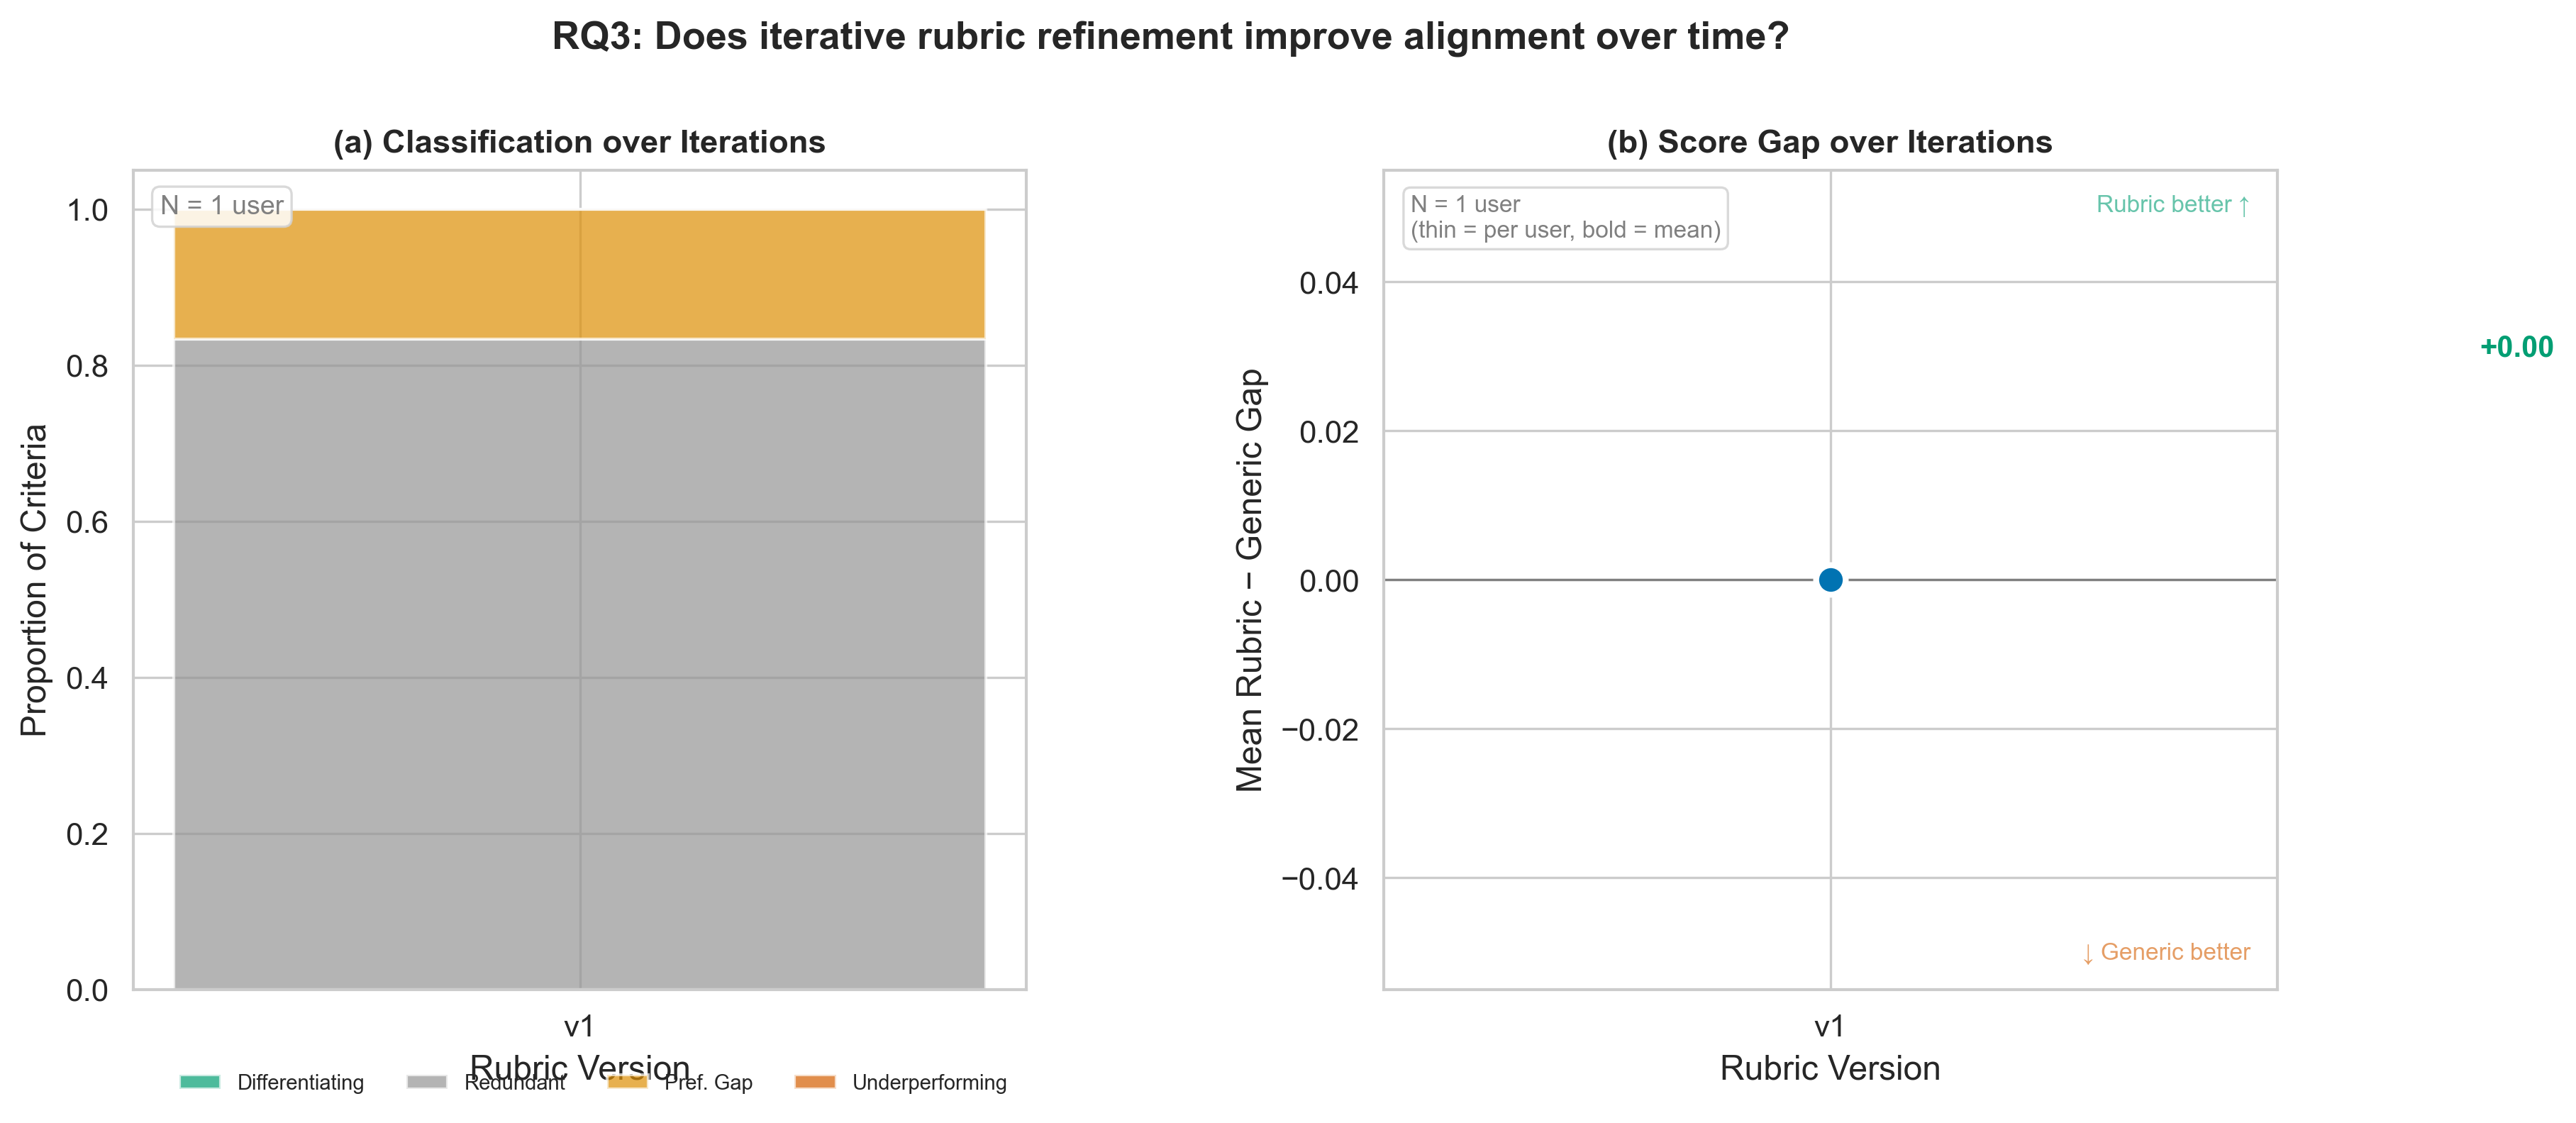

N = 1 users, 1 rubric version(s) with diagnostic data


In [154]:
# ============================================================
# RQ3 — Does iterative rubric refinement improve alignment
#        between LLM output and user preferences over time?
# ============================================================

CLASS_COLORS = {
    "DIFFERENTIATING": PALETTE[2],   # green
    "REDUNDANT": PALETTE[7],         # gray
    "PREFERENCE_GAP": PALETTE[1],    # orange
    "UNDERPERFORMING": PALETTE[3],   # red
}
CLASS_LABELS = {
    "DIFFERENTIATING": "Differentiating",
    "REDUNDANT": "Redundant",
    "PREFERENCE_GAP": "Pref. Gap",
    "UNDERPERFORMING": "Underperforming",
}

N3 = df_rq3_versions["user"].nunique() if not df_rq3_versions.empty else 0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.subplots_adjust(wspace=0.4)

# ---- (a) Classification over Iterations: Stacked bars per version ----
ax = axes[0]
if not df_rq3_criteria.empty:
    all_versions = sorted(df_rq3_criteria["rubric_version"].unique())
    users = sorted(df_rq3_criteria["user"].unique())

    # Compute pooled mean proportions per version
    means = {cls: [] for cls in CLASS_ORDER}
    valid_versions = []
    for v in all_versions:
        v_data = df_rq3_criteria[df_rq3_criteria["rubric_version"] == v]
        v_users = v_data["user"].unique()
        if len(v_users) == 0:
            continue
        valid_versions.append(v)
        for cls in CLASS_ORDER:
            per_user_pcts = []
            for u in v_users:
                u_data = v_data[v_data["user"] == u]
                n = len(u_data)
                per_user_pcts.append(
                    len(u_data[u_data["classification"] == cls]) / n if n > 0 else 0
                )
            means[cls].append(np.mean(per_user_pcts))

    x_pos = np.array(valid_versions, dtype=float)
    bottom = np.zeros(len(valid_versions))
    for cls in CLASS_ORDER:
        vals = np.array(means[cls])
        ax.bar(x_pos, vals, bottom=bottom, width=0.6,
               color=CLASS_COLORS[cls], alpha=0.7, edgecolor="white", linewidth=1,
               label=CLASS_LABELS[cls])
        bottom += vals

    ax.set_xlabel("Rubric Version")
    ax.set_ylabel("Proportion of Criteria")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(valid_versions)
    ax.set_xticklabels([f"v{int(v)}" for v in valid_versions])
    ax.legend(fontsize=7, loc="upper right",
              bbox_to_anchor=(1.0, -0.08), ncol=4, frameon=False)
    ax.text(0.03, 0.97, f"N = {N3} {'user' if N3 == 1 else 'users'}",
            transform=ax.transAxes, ha="left", va="top", fontsize=9, color="gray",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="lightgray"))
else:
    ax.text(0.5, 0.55, "Awaiting data", ha="center", va="center",
            transform=ax.transAxes, fontsize=12, color="gray")
    ax.text(0.5, 0.35,
            "Stacked bars show classification\n"
            "distribution at each rubric version.\n"
            "Green (Differentiating) should grow\n"
            "as the rubric improves.",
            ha="center", va="center", transform=ax.transAxes, fontsize=8.5,
            color="lightgray", style="italic")
ax.set_title("(a) Classification over Iterations", fontweight="bold", fontsize=11)

# ---- (b) Score Gap over Iterations: Pooled mean + user lines ----
ax = axes[1]
if not df_rq3_criteria.empty:
    all_versions = sorted(df_rq3_criteria["rubric_version"].unique())
    users = sorted(df_rq3_criteria["user"].unique())

    # Individual user lines
    for u in users:
        u_data = df_rq3_criteria[df_rq3_criteria["user"] == u]
        u_versions = sorted(u_data["rubric_version"].unique())
        u_gaps = []
        for v in u_versions:
            v_data = u_data[u_data["rubric_version"] == v]
            u_gaps.append(v_data["gap"].mean())
        ax.plot(u_versions, u_gaps, "o-", color=PALETTE[0], alpha=0.25,
                linewidth=1.2, markersize=5)

    # Pooled mean per version
    pooled_vs = []
    pooled_gaps = []
    for v in all_versions:
        v_data = df_rq3_criteria[df_rq3_criteria["rubric_version"] == v]
        v_users = v_data["user"].unique()
        if len(v_users) == 0:
            continue
        user_means = [v_data[v_data["user"] == u]["gap"].mean() for u in v_users]
        pooled_vs.append(v)
        pooled_gaps.append(np.mean(user_means))

    ax.plot(pooled_vs, pooled_gaps, "o-", color=PALETTE[0], linewidth=3, markersize=10,
            markeredgecolor="white", markeredgewidth=2, zorder=5)

    for v, g in zip(pooled_vs, pooled_gaps):
        color = PALETTE[2] if g >= 0 else PALETTE[3]
        ax.text(v + 0.08, g + 0.03, f"{g:+.2f}",
                fontsize=10, fontweight="bold", color=color)

    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("Rubric Version")
    ax.set_ylabel("Mean Rubric − Generic Gap")
    ax.set_xticks(all_versions)
    ax.set_xticklabels([f"v{int(v)}" for v in all_versions])

    ax.text(0.97, 0.97, "Rubric better ↑", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color=PALETTE[2], alpha=0.6)
    ax.text(0.97, 0.03, "↓ Generic better", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=8, color=PALETTE[3], alpha=0.6)
    ax.text(0.03, 0.97, f"N = {N3} {'user' if N3 == 1 else 'users'}\n(thin = per user, bold = mean)",
            transform=ax.transAxes, ha="left", va="top", fontsize=8, color="gray",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="lightgray"))
else:
    ax.text(0.5, 0.55, "Awaiting data", ha="center", va="center",
            transform=ax.transAxes, fontsize=12, color="gray")
    ax.text(0.5, 0.35,
            "Mean rubric − generic score gap\n"
            "over rubric versions.\n"
            "Positive = rubric outperforms generic.\n"
            "Should trend upward over iterations.",
            ha="center", va="center", transform=ax.transAxes, fontsize=8.5,
            color="lightgray", style="italic")
ax.set_title("(b) Score Gap over Iterations", fontweight="bold", fontsize=11)

fig.suptitle("RQ3: Does iterative rubric refinement improve alignment over time?",
             fontsize=13, fontweight="bold", y=1.02)
fig.savefig(OUT / "figures" / "fig03_rq3.pdf", bbox_inches="tight")
fig.savefig(OUT / "figures" / "fig03_rq3.png", bbox_inches="tight")
plt.show()

if df_rq3_criteria.empty:
    print("Awaiting alignment diagnostic data for RQ3.")
else:
    n_versions = df_rq3_criteria["rubric_version"].nunique()
    print(f"N = {N3} users, {n_versions} rubric version(s) with diagnostic data")

In [155]:
# ============================================================
# Summary Dashboard
# ============================================================

print("=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)

# Session overview
N_users = len(unique_users)
print(f"\nParticipants: {N_users}  ({', '.join(user_anon.values())})")
print(f"Projects: {len(raw_projects)}")
print(f"Conversations: {len(raw_conversations)}")
n_msgs = df_conversations["n_messages"].sum() if not df_conversations.empty else 0
n_drafts = df_conversations["n_drafts"].sum() if not df_conversations.empty else 0
print(f"Messages: {n_msgs}  |  Drafts generated: {n_drafts}")
print(f"Rubric versions: {len(df_rubric_versions)}")

# RQ1
print(f"\n--- RQ1: Iterative Elicitation (N={len(df_rq1)}) ---")
if not df_rq1.empty:
    total_s = df_rq1["stated"].sum()
    total_r = df_rq1["real"].sum()
    total_c = total_s + total_r
    stated_rate = total_s / total_c if total_c else 0
    real_rate = total_r / total_c if total_c else 0
    print(f"  Criteria (pooled): {total_s} stated + {total_r} inferred = {total_c}")
    print(f"  Stated rate: {stated_rate:.0%}  |  Inferred rate: {real_rate:.0%}")
    if not df_rq1_criteria.empty:
        crit_ranked = df_rq1_criteria[df_rq1_criteria["importance_rank"].notna()]
        if not crit_ranked.empty:
            for origin in ["stated", "real"]:
                subset = crit_ranked[crit_ranked["origin"] == origin]
                if not subset.empty:
                    print(f"  Importance rank ({origin}): mean={subset['importance_rank'].mean():.1f}, "
                          f"median={subset['importance_rank'].median():.0f}  (n={len(subset)})")

# RQ2
print(f"\n--- RQ2: Rubric-Grounding & Judge Alignment (N={len(df_rq2)}) ---")
if not df_rq2.empty:
    if not df_rq2_rank_pairs.empty:
        print("  Ranking alignment (user vs rubric judge):")
        for cond in CONDITIONS_DRAFT:
            sub = df_rq2_rank_pairs[df_rq2_rank_pairs["condition"] == cond]
            if not sub.empty:
                u_mean = sub["user_rank"].mean()
                j_mean = sub["judge_rank"].mean()
                print(f"    {COND_LABELS.get(cond, cond)}: user mean rank={u_mean:.1f}, judge mean rank={j_mean:.1f}")
    
    if not df_rq2_reliability.empty:
        print("  Grading reliability:")
        for cond in ["generic", "rubric"]:
            sub = df_rq2_reliability[df_rq2_reliability["condition"] == cond]
            if not sub.empty:
                exact = sub["exact_agreement"].mean()
                within1 = sub["within1_agreement"].mean()
                print(f"    {COND_LABELS.get(cond, cond)}: exact={exact:.0%}, within-1={within1:.0%}")
    
    if not df_rq2_draft_pref.empty:
        first_picks = df_rq2_draft_pref[df_rq2_draft_pref["rank"] == 1]
        pick_counts = first_picks["condition"].value_counts()
        print(f"  Draft preference (#1 picks): {dict(pick_counts)}")

# RQ3
print(f"\n--- RQ3: Iterative Refinement (N={N3}) ---")
if not df_rq3_versions.empty:
    n_versions = df_rq3_versions["rubric_version"].nunique()
    print(f"  Diagnostic versions: {n_versions}")
    for _, vrow in df_rq3_versions.iterrows():
        v = int(vrow["rubric_version"])
        print(f"  v{v}: {int(vrow['n_differentiating'])} diff, {int(vrow['n_redundant'])} redund, "
              f"{int(vrow['n_preference_gap'])} pref_gap, {int(vrow['n_underperforming'])} under  "
              f"| mean gap={vrow['mean_gap']:+.2f}")
else:
    print("  No alignment diagnostic data yet.")

print(f"\n{'=' * 70}")
print(f"Figures saved to: {(OUT / 'figures').resolve()}/")
print(f"Tables saved to:  {(OUT / 'tables').resolve()}/")

EVALUATION SUMMARY

Participants: 1  (P1)
Projects: 1
Conversations: 2
Messages: 12  |  Drafts generated: 6
Rubric versions: 2

--- RQ1: Iterative Elicitation (N=1) ---
  Criteria (pooled): 2 stated + 4 inferred = 6
  Stated rate: 33%  |  Inferred rate: 67%
  Importance rank (stated): mean=5.0, median=5  (n=2)
  Importance rank (real): mean=2.8, median=2  (n=4)

--- RQ2: Rubric-Grounding & Judge Alignment (N=1) ---
  Ranking alignment (user vs rubric judge):
    Generic: user mean rank=2.0, judge mean rank=3.0
    Pref-desc: user mean rank=3.0, judge mean rank=2.0
    Rubric: user mean rank=1.0, judge mean rank=1.0
  Grading reliability:
    Generic: exact=100%, within-1=100%
    Rubric: exact=67%, within-1=100%
  Draft preference (#1 picks): {'rubric': np.int64(1)}

--- RQ3: Iterative Refinement (N=1) ---
  Diagnostic versions: 1
  v1: 0 diff, 5 redund, 1 pref_gap, 0 under  | mean gap=+0.00

Figures saved to: /Users/hyeminbang/Desktop/rubricLLM/rubricLLM/eval_output/figures/
Tables sa